# Laboratorio 2 - Avance: modelos LSTM
Series utilizadas (Laboratorio 1): **Total** y **Pais de residencia: El Salvador**.

## Importes y configuracion

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(123)
np.random.seed(123)

SERIES_DIR = os.path.join("..", "..", "laboratorio1", "outputs", "series")
SEQ_LENGTH = 12

## Funciones auxiliares: carga de series y ventanas supervisadas

In [2]:
def cargar_serie(nombre):
    train = pd.read_csv(os.path.join(SERIES_DIR, f"{nombre}_train.csv"),
                        index_col=0, parse_dates=True)["viajeros"]
    test = pd.read_csv(os.path.join(SERIES_DIR, f"{nombre}_test.csv"),
                       index_col=0, parse_dates=True)["viajeros"]
    return train, test


def crear_ventanas(datos_escalados, seq_length=SEQ_LENGTH):
    x, y = [], []
    for i in range(len(datos_escalados) - seq_length):
        x.append(datos_escalados[i:i + seq_length, 0])
        y.append(datos_escalados[i + seq_length, 0])
    return np.array(x), np.array(y)


def preparar_datos(train, test, seq_length=SEQ_LENGTH):
    scaler = StandardScaler().fit(train.values.reshape(-1, 1))
    combinado = pd.concat([train, test])
    escalado = scaler.transform(combinado.values.reshape(-1, 1))
    x, y = crear_ventanas(escalado, seq_length)
    n_train = len(train) - seq_length
    x_train, y_train = x[:n_train], y[:n_train]
    x_test, y_test = x[n_train:], y[n_train:]
    x_train = x_train.reshape((x_train.shape[0], seq_length, 1))
    x_test = x_test.reshape((x_test.shape[0], seq_length, 1))
    fechas_test = combinado.index[seq_length + n_train:]
    return scaler, x_train, y_train, x_test, y_test, fechas_test

## Funciones auxiliares: construccion, tuneo y evaluacion de modelos LSTM

In [3]:
def construir_modelo(capas_unidades, dropout=0.0, learning_rate=0.01, seq_length=SEQ_LENGTH):
    modelo = keras.Sequential()
    modelo.add(keras.Input(shape=(seq_length, 1)))
    for i, unidades in enumerate(capas_unidades):
        modelo.add(layers.LSTM(unidades, return_sequences=i < len(capas_unidades) - 1))
        if dropout > 0:
            modelo.add(layers.Dropout(dropout))
    modelo.add(layers.Dense(1))
    modelo.compile(optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
                   loss="mse", metrics=[keras.metrics.RootMeanSquaredError()])
    return modelo


def tunear_modelo(x_train, y_train, configuraciones, epocas=150):
    mejor, resultados = None, []
    for cfg in configuraciones:
        modelo = construir_modelo(cfg["capas"], cfg.get("dropout", 0.0), cfg["lr"])
        parada = keras.callbacks.EarlyStopping(monitor="val_loss", patience=12,
                                               restore_best_weights=True)
        historia = modelo.fit(x_train, y_train, epochs=epocas, validation_split=0.15,
                              shuffle=True, callbacks=[parada], verbose=0)
        val_loss = min(historia.history["val_loss"])
        resultados.append({**cfg, "val_loss": val_loss})
        if mejor is None or val_loss < mejor["val_loss"]:
            mejor = {**cfg, "val_loss": val_loss, "modelo": modelo, "historia": historia}
    return mejor, pd.DataFrame(resultados).sort_values("val_loss")


def evaluar_en_prueba(modelo, x_test, y_test, scaler):
    pred_escalada = modelo.predict(x_test, verbose=0)
    prediccion = scaler.inverse_transform(pred_escalada).flatten()
    real = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
    mae = mean_absolute_error(real, prediccion)
    rmse = np.sqrt(mean_squared_error(real, prediccion))
    return prediccion, real, mae, rmse

## Serie: Total mensual de viajeros

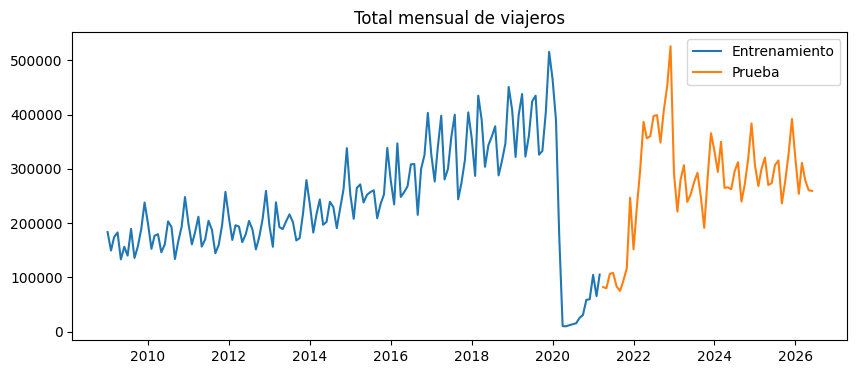

In [4]:
train_total, test_total = cargar_serie("Total")

plt.figure(figsize=(10, 4))
plt.plot(train_total, label="Entrenamiento")
plt.plot(test_total, label="Prueba")
plt.title("Total mensual de viajeros")
plt.legend()
plt.show()

### Preparacion de datos (escalado y ventanas de 12 meses)

In [5]:
scaler_total, x_train_total, y_train_total, x_test_total, y_test_total, fechas_test_total = \
    preparar_datos(train_total, test_total)
x_train_total.shape, x_test_total.shape

((135, 12, 1), (63, 12, 1))

### Modelo 1: LSTM de una capa (tuneo de unidades y learning rate)

In [6]:
configs_modelo1_total = [
    {"capas": [16], "lr": 0.01},
    {"capas": [32], "lr": 0.01},
    {"capas": [32], "lr": 0.005},
    {"capas": [64], "lr": 0.005},
]
mejor1_total, tabla1_total = tunear_modelo(x_train_total, y_train_total, configs_modelo1_total)
tabla1_total

,capas,lr,val_loss
3,[64],0.005,1.949892
0,[16],0.010,2.364695
2,[32],0.005,2.449272
1,[32],0.010,2.517335


### Modelo 2: LSTM apilada de dos capas (tuneo de unidades y dropout)

In [7]:
configs_modelo2_total = [
    {"capas": [32, 16], "dropout": 0.0, "lr": 0.005},
    {"capas": [32, 16], "dropout": 0.2, "lr": 0.005},
    {"capas": [64, 32], "dropout": 0.2, "lr": 0.005},
]
mejor2_total, tabla2_total = tunear_modelo(x_train_total, y_train_total, configs_modelo2_total)
tabla2_total

,capas,dropout,lr,val_loss
2,"[64, 32]",0.2,0.005,2.926368
1,"[32, 16]",0.2,0.005,3.159018
0,"[32, 16]",0.0,0.005,3.294221


### Comparacion de los dos modelos LSTM sobre el conjunto de prueba

                  modelo           MAE          RMSE
0       LSTM 1 capa [64]  51299.709589  67634.727321
1  LSTM 2 capas [64, 32]  58007.825288  77448.391005


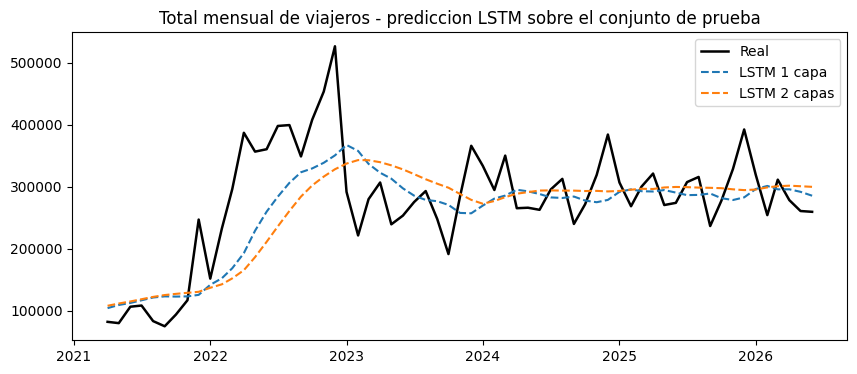

In [8]:
pred1_total, real_total, mae1_total, rmse1_total = \
    evaluar_en_prueba(mejor1_total["modelo"], x_test_total, y_test_total, scaler_total)
pred2_total, _, mae2_total, rmse2_total = \
    evaluar_en_prueba(mejor2_total["modelo"], x_test_total, y_test_total, scaler_total)

resumen_total = pd.DataFrame([
    {"modelo": f"LSTM 1 capa {mejor1_total['capas']}", "MAE": mae1_total, "RMSE": rmse1_total},
    {"modelo": f"LSTM 2 capas {mejor2_total['capas']}", "MAE": mae2_total, "RMSE": rmse2_total},
])
print(resumen_total)

plt.figure(figsize=(10, 4))
plt.plot(fechas_test_total, real_total, label="Real", color="black", lw=1.8)
plt.plot(fechas_test_total, pred1_total, label="LSTM 1 capa", ls="--")
plt.plot(fechas_test_total, pred2_total, label="LSTM 2 capas", ls="--")
plt.title("Total mensual de viajeros - prediccion LSTM sobre el conjunto de prueba")
plt.legend()
plt.show()

## Serie: Pais de residencia: El Salvador

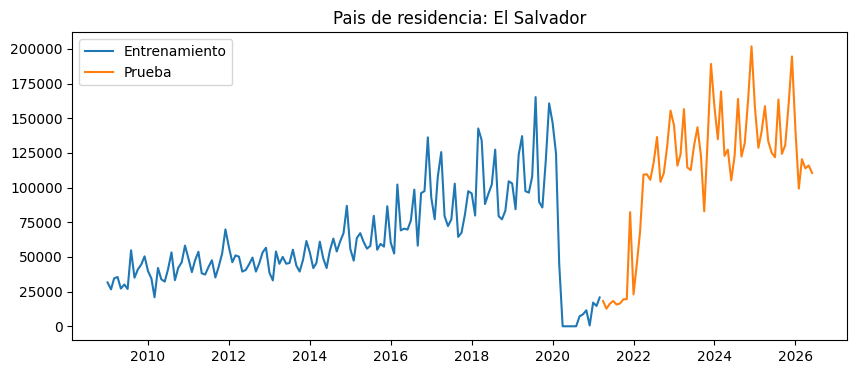

In [9]:
train_elsalvador, test_elsalvador = cargar_serie("Pais_ElSalvador")

plt.figure(figsize=(10, 4))
plt.plot(train_elsalvador, label="Entrenamiento")
plt.plot(test_elsalvador, label="Prueba")
plt.title("Pais de residencia: El Salvador")
plt.legend()
plt.show()

### Preparacion de datos (escalado y ventanas de 12 meses)

In [10]:
scaler_elsalvador, x_train_elsalvador, y_train_elsalvador, x_test_elsalvador, y_test_elsalvador, fechas_test_elsalvador = \
    preparar_datos(train_elsalvador, test_elsalvador)
x_train_elsalvador.shape, x_test_elsalvador.shape

((135, 12, 1), (63, 12, 1))

### Modelo 1: LSTM de una capa (tuneo de unidades y learning rate)

In [11]:
configs_modelo1_elsalvador = [
    {"capas": [16], "lr": 0.01},
    {"capas": [32], "lr": 0.01},
    {"capas": [32], "lr": 0.005},
    {"capas": [64], "lr": 0.005},
]
mejor1_elsalvador, tabla1_elsalvador = tunear_modelo(x_train_elsalvador, y_train_elsalvador, configs_modelo1_elsalvador)
tabla1_elsalvador

,capas,lr,val_loss
0,[16],0.010,1.993183
3,[64],0.005,2.008447
1,[32],0.010,2.163130
2,[32],0.005,2.238608


### Modelo 2: LSTM apilada de dos capas (tuneo de unidades y dropout)

In [12]:
configs_modelo2_elsalvador = [
    {"capas": [32, 16], "dropout": 0.0, "lr": 0.005},
    {"capas": [32, 16], "dropout": 0.2, "lr": 0.005},
    {"capas": [64, 32], "dropout": 0.2, "lr": 0.005},
]
mejor2_elsalvador, tabla2_elsalvador = tunear_modelo(x_train_elsalvador, y_train_elsalvador, configs_modelo2_elsalvador)
tabla2_elsalvador

,capas,dropout,lr,val_loss
2,"[64, 32]",0.2,0.005,2.647958
0,"[32, 16]",0.0,0.005,2.819702
1,"[32, 16]",0.2,0.005,3.103017


### Comparacion de los dos modelos LSTM sobre el conjunto de prueba

                  modelo           MAE          RMSE
0       LSTM 1 capa [16]  30598.718964  37603.983538
1  LSTM 2 capas [64, 32]  35434.478543  42663.211547


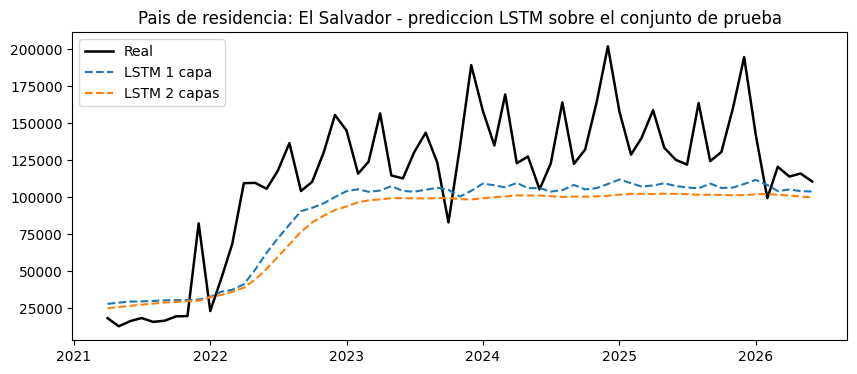

In [13]:
pred1_elsalvador, real_elsalvador, mae1_elsalvador, rmse1_elsalvador = \
    evaluar_en_prueba(mejor1_elsalvador["modelo"], x_test_elsalvador, y_test_elsalvador, scaler_elsalvador)
pred2_elsalvador, _, mae2_elsalvador, rmse2_elsalvador = \
    evaluar_en_prueba(mejor2_elsalvador["modelo"], x_test_elsalvador, y_test_elsalvador, scaler_elsalvador)

resumen_elsalvador = pd.DataFrame([
    {"modelo": f"LSTM 1 capa {mejor1_elsalvador['capas']}", "MAE": mae1_elsalvador, "RMSE": rmse1_elsalvador},
    {"modelo": f"LSTM 2 capas {mejor2_elsalvador['capas']}", "MAE": mae2_elsalvador, "RMSE": rmse2_elsalvador},
])
print(resumen_elsalvador)

plt.figure(figsize=(10, 4))
plt.plot(fechas_test_elsalvador, real_elsalvador, label="Real", color="black", lw=1.8)
plt.plot(fechas_test_elsalvador, pred1_elsalvador, label="LSTM 1 capa", ls="--")
plt.plot(fechas_test_elsalvador, pred2_elsalvador, label="LSTM 2 capas", ls="--")
plt.title("Pais de residencia: El Salvador - prediccion LSTM sobre el conjunto de prueba")
plt.legend()
plt.show()

## Resumen del avance

In [14]:
resumen_general = pd.concat([
    resumen_total.assign(serie="Total"),
    resumen_elsalvador.assign(serie="Pais_ElSalvador"),
])[["serie", "modelo", "MAE", "RMSE"]]
resumen_general

,serie,modelo,MAE,RMSE
0,Total,LSTM 1 capa [64],51299.709589,67634.727321
1,Total,"LSTM 2 capas [64, 32]",58007.825288,77448.391005
0,Pais_ElSalvador,LSTM 1 capa [16],30598.718964,37603.983538
1,Pais_ElSalvador,"LSTM 2 capas [64, 32]",35434.478543,42663.211547
